# Evagene risk explorer (Python / Jupyter)

A **what-if** tour of Evagene's risk outputs — one cell per question, one
chart per answer. Pick a pedigree from your account and step through:

1. **Setup** — load the API key from the environment.
2. **Pick a pedigree** — choose the family to work with.
3. **Baseline NICE category** — green / amber / red on that family as it stands.
4. **Add an affected sister** — clone the pedigree into a scratch copy, add a
   synthetic first-degree relative with breast cancer, and re-run NICE.
5. **Tyrer-Cuzick slider** — sweep the proband's reproductive-history inputs and
   chart the 10-year / lifetime risk surface.
6. **Multifactorial under varied heritability** — Falconer liability-threshold
   intuition against several heritable diseases on the same family structure.
7. **Caveats and suggested reading.**

**The scratch pedigree is created in Section 4 and deleted in Section 7.**
If the notebook aborts mid-way, find the orphan in the Evagene web UI
(it is named `[scratch] notebook-explorer ...`) and delete it by hand.

## 1. Setup

The notebook uses a small client module (`notebook_explorer.client.EvageneClient`)
whose only job is to make the cells below short. The key lives in an
environment variable — never in a cell.

> **First-time setup:** copy `.env.example` to `.env`, paste in your Evagene
> API key (scopes `read` + `write` + `analyze`), and start Jupyter from a
> shell that has that environment loaded.

In [1]:
import os
import time
from datetime import datetime, timezone

import matplotlib.pyplot as plt

from notebook_explorer import EvageneClient, HttpxGateway, load_config

# Tolerate a ``.env`` file sitting next to this notebook (or in any
# parent directory up to the repo root) for convenience when launching
# Jupyter from outside a dotenv-aware shell.
def _load_dotenv() -> None:
    here = os.path.abspath(".")
    for _ in range(5):
        candidate = os.path.join(here, ".env")
        if os.path.exists(candidate):
            for _line in open(candidate, encoding="utf-8"):
                _line = _line.strip()
                if _line and not _line.startswith("#") and "=" in _line:
                    _k, _, _v = _line.partition("=")
                    os.environ.setdefault(_k.strip(), _v.strip())
            return
        parent = os.path.dirname(here)
        if parent == here:
            return
        here = parent


_load_dotenv()

config = load_config(os.environ)
client = EvageneClient(
    base_url=config.base_url,
    api_key=config.api_key,
    http=HttpxGateway(),
)
print(f"Ready. Base URL: {config.base_url}")

Ready. Base URL: https://evagene.net


## 2. Pick a pedigree

The list is pulled from `GET /api/pedigrees`. Each row links back to the web
UI. Copy the ID you want to explore into the cell below.

In [2]:
from IPython.display import Markdown

pedigrees = client.get_pedigrees()

_rows = ["| # | Name | Link | ID |", "|---|---|---|---|"]
for _i, _p in enumerate(pedigrees):
    _name = _p.get("display_name") or "(untitled)"
    _pid = _p.get("id", "")
    _url = client.evagene_url(_pid)
    _rows.append(f"| {_i} | {_name} | [open]({_url}) | `{_pid}` |")

Markdown("\n".join(_rows))

| # | Name | Link | ID |
|---|---|---|---|
| 0 | British Royal Family — Haemophilia & Consanguinity | [open](https://evagene.net/pedigrees/c81d9370-6733-4e97-9aff-33dab03e2b1f) | `c81d9370-6733-4e97-9aff-33dab03e2b1f` |
| 1 | Consanguinity — Double First Cousins (SMA) | [open](https://evagene.net/pedigrees/eafdcdb4-8ec8-4a6d-a146-41b0d18edd89) | `eafdcdb4-8ec8-4a6d-a146-41b0d18edd89` |
| 2 | Consanguinity — First Cousin Marriage (PKU) | [open](https://evagene.net/pedigrees/8e0742ff-fcc1-4c60-8b36-187be50c028d) | `8e0742ff-fcc1-4c60-8b36-187be50c028d` |
| 3 | Cystic Fibrosis Family | [open](https://evagene.net/pedigrees/b8029ad2-eb8d-4648-96ce-9fc95ff9684b) | `b8029ad2-eb8d-4648-96ce-9fc95ff9684b` |
| 4 | Duchenne Muscular Dystrophy Family | [open](https://evagene.net/pedigrees/c0f8d263-ccae-408b-9515-6b93dc5d925f) | `c0f8d263-ccae-408b-9515-6b93dc5d925f` |
| 5 | Familial Hypercholesterolaemia Family | [open](https://evagene.net/pedigrees/d802aafd-a9b1-4997-b1ae-3559bb328f27) | `d802aafd-a9b1-4997-b1ae-3559bb328f27` |
| 6 | Breast Cancer | [open](https://evagene.net/pedigrees/a1cfe665-2e95-4386-9eb8-53d46095478a) | `a1cfe665-2e95-4386-9eb8-53d46095478a` |
| 7 | Fragile X Syndrome Family | [open](https://evagene.net/pedigrees/ca5f98ac-bc5a-4102-ad3b-35a5a200652e) | `ca5f98ac-bc5a-4102-ad3b-35a5a200652e` |
| 8 | adrian_pickering_family_tree_download | [open](https://evagene.net/pedigrees/8697a5bf-1dcf-414e-9cff-9839232b8834) | `8697a5bf-1dcf-414e-9cff-9839232b8834` |
| 9 | Family | [open](https://evagene.net/pedigrees/9a529c3e-11f3-4f14-b129-5c8841e5ada4) | `9a529c3e-11f3-4f14-b129-5c8841e5ada4` |
| 10 | Blood Type & Rh Factor Inheritance — ABO and RHD SNP Markers | [open](https://evagene.net/pedigrees/5776f4b9-da1b-40e1-a798-6f58b345cd7e) | `5776f4b9-da1b-40e1-a798-6f58b345cd7e` |
| 11 | Huntington's Disease Family | [open](https://evagene.net/pedigrees/f9fe4802-61ce-4cdf-91bc-f8bd9f64a167) | `f9fe4802-61ce-4cdf-91bc-f8bd9f64a167` |
| 12 | Blood Type & Rh Factor Inheritance — ABO and RHD SNP Markers | [open](https://evagene.net/pedigrees/ecb6d635-5eed-4b02-a7bb-a9ed3575a88a) | `ecb6d635-5eed-4b02-a7bb-a9ed3575a88a` |
| 13 | Major Depressive Disorder — Multifactorial Family Pattern | [open](https://evagene.net/pedigrees/a8b68255-c9ff-4b2f-9eb7-1658541c44a4) | `a8b68255-c9ff-4b2f-9eb7-1658541c44a4` |
| 14 | Monozygotic Twins — Cystic Fibrosis Concordance | [open](https://evagene.net/pedigrees/7e06b187-6649-4868-99bc-344c72146726) | `7e06b187-6649-4868-99bc-344c72146726` |
| 15 | Multi-Disease Risk Screening — Breast Cancer, Colon Cancer, and FH | [open](https://evagene.net/pedigrees/f71e6468-7b7f-4898-bfb1-c075a77392cf) | `f71e6468-7b7f-4898-bfb1-c075a77392cf` |
| 16 | Anchored Notes & AI Report â€” HBOC Family with BRCA1 | [open](https://evagene.net/pedigrees/98bcd6be-4802-4c84-9c45-b4f62a6b86a3) | `98bcd6be-4802-4c84-9c45-b4f62a6b86a3` |
| 17 | Blood Type & Rh Factor Inheritance — ABO and RHD SNP Markers | [open](https://evagene.net/pedigrees/fdf96e1e-ba52-4454-8d5e-73577c5457a5) | `fdf96e1e-ba52-4454-8d5e-73577c5457a5` |
| 18 | Secretor Status — FUT2 Gene and Norovirus Resistance | [open](https://evagene.net/pedigrees/ae7844df-c37f-4f24-9a44-ef7fcaa1304a) | `ae7844df-c37f-4f24-9a44-ef7fcaa1304a` |
| 19 | Prothrombin G20210A Thrombophilia — Factor II Variant Family | [open](https://evagene.net/pedigrees/466d1b66-f4e5-4dce-ac92-afc58f8a11a3) | `466d1b66-f4e5-4dce-ac92-afc58f8a11a3` |
| 20 | (untitled) | [open](https://evagene.net/pedigrees/08a662c6-06a0-4a9e-adf9-39bb81a0256b) | `08a662c6-06a0-4a9e-adf9-39bb81a0256b` |
| 21 | (untitled) | [open](https://evagene.net/pedigrees/e02e3eef-8f89-440d-8df0-6336c1968430) | `e02e3eef-8f89-440d-8df0-6336c1968430` |
| 22 | Pickerings | [open](https://evagene.net/pedigrees/ace9e15b-cd17-455c-a616-48544a3995d7) | `ace9e15b-cd17-455c-a616-48544a3995d7` |
| 23 | Emma Carter's family | [open](https://evagene.net/pedigrees/5afed995-2973-479e-8b9a-38e11e8441ed) | `5afed995-2973-479e-8b9a-38e11e8441ed` |
| 24 | Emma Carter's family | [open](https://evagene.net/pedigrees/e30a1f55-7467-468c-8e65-76130585b43b) | `e30a1f55-7467-468c-8e65-76130585b43b` |
| 25 | Emma Carter's family | [open](https://evagene.net/pedigrees/943e5d03-d2c7-4f43-a5f7-918dcdaf374c) | `943e5d03-d2c7-4f43-a5f7-918dcdaf374c` |

Set `PEDIGREE_ID` below to the UUID of the pedigree you want to
explore. The default points at the first pedigree on the account — swap it
for a family with an affected breast-cancer relative if you want the NICE /
Tyrer-Cuzick sections to produce the most interesting numbers.

In [3]:
# Default: prefer a pedigree whose display_name mentions "breast" (so
# the NICE and Tyrer-Cuzick sections produce meaningful numbers); fall
# back to the first pedigree otherwise.  Override by setting PEDIGREE_ID
# to any UUID from the table above.
selected = next(
    (p for p in pedigrees
     if "breast" in (p.get("display_name") or "").lower()),
    pedigrees[0],
)
PEDIGREE_ID = selected["id"]
print(f"Selected: {selected.get('display_name')}")
print(f"Link:     {client.evagene_url(PEDIGREE_ID)}")

Selected: Breast Cancer
Link:     https://evagene.net/pedigrees/a1cfe665-2e95-4386-9eb8-53d46095478a


## 3. Baseline NICE category

One call to `POST /api/pedigrees/{id}/risk/calculate` with `model=NICE`.
The response carries `cancer_risk.nice_category` (one of `near_population`,
`moderate`, `high`), the triggers that fired, and human-readable notes.

In [4]:
_TRAFFIC_LIGHTS = {
    "near_population": "GREEN",
    "moderate": "AMBER",
    "high": "RED",
}


def summarise_nice(payload: dict) -> str:
    cr = payload.get("cancer_risk") or {}
    category = cr.get("nice_category", "unknown")
    triggers = cr.get("nice_triggers") or []
    notes = cr.get("notes") or []
    light = _TRAFFIC_LIGHTS.get(category, "unknown")
    lines = [f"NICE category: {category.upper()} ({light})"]
    lines.append(f"Triggers: {list(triggers) if triggers else 'none'}")
    if notes:
        lines.append(f"Note: {notes[0]}")
    return "\n".join(lines)


baseline_nice = client.run_risk(PEDIGREE_ID, "NICE")
print(summarise_nice(baseline_nice))

NICE category: NEAR_POPULATION (GREEN)
Triggers: none
Note: Near-population risk (NICE <17% lifetime) — no enhanced surveillance required; reassure and discharge to primary care.


## 4. What if we add affected first-degree relatives?

This is where the scratch clone comes in. The notebook:

1. Clones the pedigree via a GEDCOM round-trip (export → create → import).
2. Adds a synthetic sister to the proband; flags the sister and (if present)
   the mother affected with breast cancer.
3. Re-runs the NICE calculation on the scratch copy.

Two affected first-degree relatives is the textbook NICE "moderate"
(amber) trigger. The original pedigree is never touched. The clone is
deleted in the closing cell (Section 7).

In [5]:
_suffix = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
SCRATCH_ID = client.clone_pedigree_for_exploration(
    PEDIGREE_ID, scratch_suffix=_suffix,
)
print(f"Scratch pedigree: {client.evagene_url(SCRATCH_ID)}")

Scratch pedigree: https://evagene.net/pedigrees/737d050f-81ea-4db3-a3ff-ca1392735f75


In [6]:
# We need the scratch proband's ID and a "Breast Cancer" disease ID.
# The register endpoint gives us the proband; we look up the breast-cancer
# disease by display name in the disease catalogue so the demo works
# regardless of which diseases were attached to the pedigree you picked.
import httpx

register = client.get_register(SCRATCH_ID)
proband_id = register.get("proband_id")
print(f"Scratch proband: {proband_id}")

_disease_catalogue = httpx.get(
    f"{config.base_url}/api/diseases",
    headers={"X-API-Key": config.api_key, "Accept": "application/json"},
    timeout=30,
).json()
breast_cancer = next(
    (d for d in _disease_catalogue
     if (d.get("display_name") or "").strip() == "Breast Cancer"),
    None,
)
if breast_cancer is None:
    raise RuntimeError("No 'Breast Cancer' disease in your catalogue; cannot continue section 4.")
BREAST_CANCER_ID = breast_cancer["id"]
print(f"Breast Cancer disease id: {BREAST_CANCER_ID}")
client.add_disease_to_pedigree(SCRATCH_ID, BREAST_CANCER_ID)

Scratch proband: 42ac99d7-9bc7-4e45-b7e7-aa09f5f1e17c


Breast Cancer disease id: 75098e49-7628-55f1-b34e-b8ab27e36ee0


In [7]:
# Add an affected sister.  The new individual is returned with her ID.
sister = client.add_relative(
    SCRATCH_ID,
    relative_of=proband_id,
    relative_type="sister",
    display_name="Synthetic sister",
    biological_sex="female",
)
sister_id = sister["individual"]["id"]
print(f"Sister id: {sister_id}")

client.add_disease_to_individual(
    sister_id,
    disease_id=BREAST_CANCER_ID,
    age_at_diagnosis=38,
)

# Also mark the mother affected (two affected first-degree relatives is
# the textbook NICE "moderate" trigger — one affected sister alone does
# not reliably cross the threshold for every family structure).
mother_row = next(
    (r for r in register["rows"]
     if r.get("relationship_to_proband") == "Mother"),
    None,
)
if mother_row is not None:
    client.add_disease_to_individual(
        mother_row["individual_id"],
        disease_id=BREAST_CANCER_ID,
        age_at_diagnosis=45,
    )
    print("Marked sister and mother affected with Breast Cancer.")
else:
    print("Marked sister affected with Breast Cancer (no mother in the pedigree).")

Sister id: a83c08be-e76d-4b47-9100-fd72f67edd9a


Marked sister and mother affected with Breast Cancer.


In [8]:
after_nice = client.run_risk(SCRATCH_ID, "NICE")
print("BEFORE:")
print(summarise_nice(baseline_nice))
print()
print("AFTER:")
print(summarise_nice(after_nice))

BEFORE:
NICE category: NEAR_POPULATION (GREEN)
Triggers: none
Note: Near-population risk (NICE <17% lifetime) — no enhanced surveillance required; reassure and discharge to primary care.

AFTER:
NICE category: MODERATE (AMBER)
Triggers: ['Two first-degree relatives with breast cancer, both 50 or over.']
Note: Moderate risk (NICE lifetime 17-30%) — routine surveillance and specialist advice; refer if further significant history emerges.


## 5. Tyrer-Cuzick slider

`TYRER_CUZICK` reads the **proband's** reproductive-history fields:
`age_at_menarche`, `parity`, `age_at_first_live_birth`,
`breast_density_birads` (BI-RADS 1–4), `hormone_therapy_years`, and so on.
They live on the individual record, not the risk-request body — so this
section mutates them on the scratch proband and re-runs TC for each
combination.

The request rate is held below the 60-per-minute server limit with a small
pause between calls.

In [9]:
MENARCHE_AGES = (10, 13)
PARITIES = (0, 2)
BIRADS_LEVELS = (1, 2, 3, 4)

results: list[dict] = []
for menarche in MENARCHE_AGES:
    for parity in PARITIES:
        for birads in BIRADS_LEVELS:
            client.patch_individual(
                proband_id,
                age_at_menarche=menarche,
                parity=parity,
                breast_density_birads=birads,
                age_at_first_live_birth=28 if parity else None,
            )
            time.sleep(0.4)  # avoid the 60/min rate limit with headroom
            tc = client.run_risk(SCRATCH_ID, "TYRER_CUZICK")
            cancer_risk = tc.get("cancer_risk") or {}
            results.append({
                "menarche": menarche,
                "parity": parity,
                "birads": birads,
                "ten_year": cancer_risk.get("tc_ten_year_risk"),
                "lifetime": cancer_risk.get("tc_lifetime_risk"),
            })

print(f"TC results: {len(results)} points")

TC results: 16 points


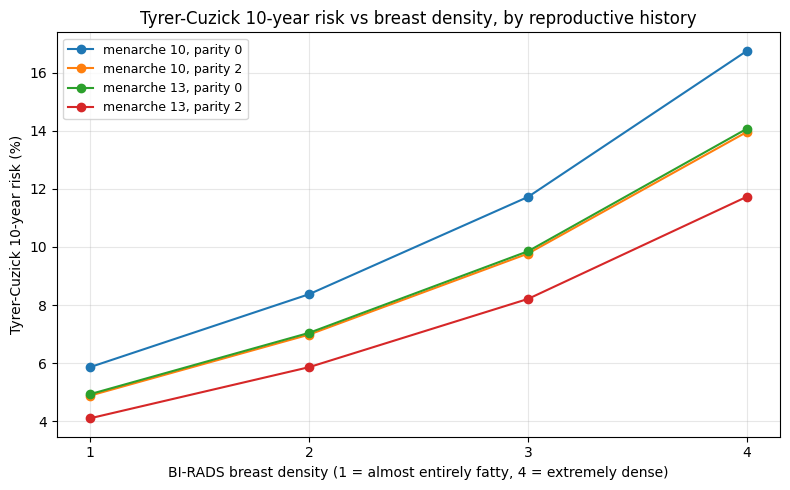

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for menarche in MENARCHE_AGES:
    for parity in PARITIES:
        xs = [r["birads"] for r in results
              if r["menarche"] == menarche and r["parity"] == parity
              and r["ten_year"] is not None]
        ys = [r["ten_year"] * 100 for r in results
              if r["menarche"] == menarche and r["parity"] == parity
              and r["ten_year"] is not None]
        if xs:
            ax.plot(
                xs, ys, marker="o",
                label=f"menarche {menarche}, parity {parity}",
            )
ax.set_xticks([1, 2, 3, 4])
ax.set_xlabel("BI-RADS breast density (1 = almost entirely fatty, 4 = extremely dense)")
ax.set_ylabel("Tyrer-Cuzick 10-year risk (%)")
ax.set_title("Tyrer-Cuzick 10-year risk vs breast density, by reproductive history")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

Reading the chart: each curve holds `age_at_menarche` and `parity`
constant while BI-RADS walks from 1 (fatty) to 4 (extremely dense). Denser
breasts drag risk up steeply; higher parity (with age at first live birth
fixed at 28) shifts the whole curve down — the classic protective effect.

## 6. Multifactorial under varied heritability

The multifactorial (Falconer liability-threshold) model takes a disease's
`heritability` ($h^2$) and `population_prevalence` ($K$), plus the affected-
relative structure, and returns a recurrence risk for the proband.

`/risk/calculate` does **not** accept a request-level $h^2$ override, so to
trace the curve the notebook runs the model once per disease against the
(sister-is-affected) scratch family. Each disease is a point on the $h^2$
axis; reading risk against $h^2$ shows how the liability-threshold model
ramps up recurrence risk as heritability rises — here at fixed "one
affected first-degree relative" structure.

In [11]:
# Pull the disease catalogue to find diseases with heritability set.
import httpx

_resp = httpx.get(
    f"{config.base_url}/api/diseases",
    headers={"X-API-Key": config.api_key, "Accept": "application/json"},
    timeout=30,
)
all_diseases = _resp.json() if _resp.status_code == 200 else []
heritable = [d for d in all_diseases if d.get("heritability")]
print(f"{len(heritable)} heritable diseases in the catalogue.")

# Pick a handful spanning the h2 range.
picks = sorted(heritable, key=lambda d: d["heritability"])
NAMES = [
    "Major Depressive Disorder (Familial)",
    "Type 2 Diabetes (Familial)",
    "Epilepsy (Familial)",
    "Cleft Lip With or Without Cleft Palate",
    "Schizophrenia (Familial)",
    "Bipolar Disorder (Familial)",
    "Coeliac Disease",
    "Ankylosing Spondylitis",
]
_by_name = {d["display_name"]: d for d in heritable}
picks = [_by_name[n] for n in NAMES if n in _by_name]
for d in picks:
    print(f"  h2={d['heritability']:.2f}  K={d.get('population_prevalence')}  {d['display_name']}")

23 heritable diseases in the catalogue.
  h2=0.40  K=0.1  Major Depressive Disorder (Familial)
  h2=0.60  K=0.08  Type 2 Diabetes (Familial)
  h2=0.70  K=0.005  Epilepsy (Familial)
  h2=0.76  K=0.001  Cleft Lip With or Without Cleft Palate
  h2=0.80  K=0.01  Schizophrenia (Familial)
  h2=0.85  K=0.01  Bipolar Disorder (Familial)
  h2=0.87  K=0.01  Coeliac Disease
  h2=0.90  K=0.005  Ankylosing Spondylitis


In [12]:
# For each disease: add it to the scratch pedigree's working set, make the
# synthetic sister affected with it, and run MULTIFACTORIAL with the
# disease as the target.

mf_rows: list[dict] = []
for d in picks:
    did = d["id"]
    client.add_disease_to_pedigree(SCRATCH_ID, did)
    time.sleep(0.3)
    client.add_disease_to_individual(
        sister_id, disease_id=did, age_at_diagnosis=30,
    )
    time.sleep(0.3)
    out = client.run_risk(SCRATCH_ID, "MULTIFACTORIAL", disease_id=did)
    block = out.get("multifactorial") or {}
    mf_rows.append({
        "disease": d["display_name"],
        "h2": d["heritability"],
        "K": d.get("population_prevalence"),
        "final_risk": block.get("final_risk"),
        "base_risk": block.get("base_risk"),
        "base_source": block.get("base_source"),
        "nearest_class": block.get("nearest_class"),
    })

for row in mf_rows:
    print(row)

{'disease': 'Major Depressive Disorder (Familial)', 'h2': 0.4, 'K': 0.1, 'final_risk': 0.2, 'base_risk': 0.2, 'base_source': 'empirical_table', 'nearest_class': 'first_degree'}
{'disease': 'Type 2 Diabetes (Familial)', 'h2': 0.6, 'K': 0.08, 'final_risk': 0.3, 'base_risk': 0.3, 'base_source': 'empirical_table', 'nearest_class': 'first_degree'}
{'disease': 'Epilepsy (Familial)', 'h2': 0.7, 'K': 0.005, 'final_risk': 0.04, 'base_risk': 0.04, 'base_source': 'empirical_table', 'nearest_class': 'first_degree'}
{'disease': 'Cleft Lip With or Without Cleft Palate', 'h2': 0.76, 'K': 0.001, 'final_risk': 0.074286, 'base_risk': 0.04, 'base_source': 'empirical_table', 'nearest_class': 'first_degree'}
{'disease': 'Schizophrenia (Familial)', 'h2': 0.8, 'K': 0.01, 'final_risk': 0.1, 'base_risk': 0.1, 'base_source': 'empirical_table', 'nearest_class': 'first_degree'}
{'disease': 'Bipolar Disorder (Familial)', 'h2': 0.85, 'K': 0.01, 'final_risk': 0.08, 'base_risk': 0.08, 'base_source': 'empirical_table'

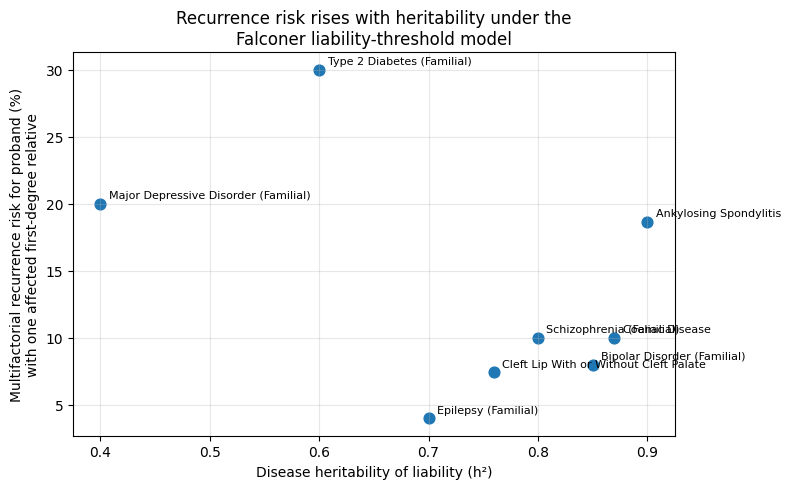

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = [r["h2"] for r in mf_rows if r["final_risk"] is not None]
ys = [r["final_risk"] * 100 for r in mf_rows if r["final_risk"] is not None]
labels = [r["disease"] for r in mf_rows if r["final_risk"] is not None]

ax.scatter(xs, ys, s=60)
for x, y, lab in zip(xs, ys, labels, strict=True):
    ax.annotate(lab, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_xlabel("Disease heritability of liability (h²)")
ax.set_ylabel("Multifactorial recurrence risk for proband (%)\n"
              "with one affected first-degree relative")
ax.set_title("Recurrence risk rises with heritability under the\n"
             "Falconer liability-threshold model")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Each point is a real disease, run through Evagene's multifactorial
engine against the same synthetic family structure (one affected first-degree
relative, otherwise unaffected). Population prevalence varies across diseases
and also drives the curve — the Falconer model is a joint function of
$h^2$ and $K$, so the points do not fall on a single line. That is the
teaching point: heritability is a lever, not a knob.

## 7. Caveats and cleanup

The final cell deletes the scratch pedigree. If a preceding cell raised,
run this cell manually before retrying — otherwise the scratch copy stays
in your account.

In [14]:
client.delete_pedigree(SCRATCH_ID)
print(f"Scratch pedigree {SCRATCH_ID} deleted. Your original is untouched.")

Scratch pedigree 737d050f-81ea-4db3-a3ff-ca1392735f75 deleted. Your original is untouched.


### Caveats

- **Tyrer-Cuzick** is an IBIS-style approximation, not the licensed IBIS
  tool. **BOADICEA** is not bundled; for the full multi-gene / polygenic-
  risk-score version, export a CanRisk v2 file from the pedigree and upload
  at [canrisk.org](https://canrisk.org).
- **Multifactorial recurrence risk** shown here is Evagene's Falconer
  liability-threshold output with Carter-effect and consanguinity modifiers.
  Published empirical recurrence tables (when they exist) are a better
  source for the specific disease.
- These are example integrations, **not validated clinical tools**.

### Suggested reading

- Falconer DS. *Ann Hum Genet* 1965 — the liability-threshold foundation.
- Tyrer J, Duffy SW, Cuzick J. *Stat Med* 2004 — the IBIS breast-cancer model.
- NICE CG164 / NG101 — family-history triage rules driving the NICE category.
- Parmigiani et al. *Am J Hum Genet* 1998 — BRCAPRO, the Bayesian counterpart.